# Library

This notebook loads the Excel file **`banco de dados daniel.xlsx`** (sheet: **`Dataset com TS variável`**), computes descriptive statistics.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

# Dataset Description

In [2]:
import pandas as pd

file_path = "banco de dados daniel.xlsx"
sheet_name = "Dataset sem TS"
df = pd.read_excel(file_path, sheet_name=sheet_name)
n_rows, n_cols = df.shape
print(f"Rows: {n_rows}, Cols: {n_cols}")
display(df.head())
df.info()

Rows: 341, Cols: 10


,Autor,Diâmetro da armadura (mm),Número de barras em uma camada,Espaçamento entre as barras (mm),Resistência à tração do concreto (MPa),Cobrimento (mm),Distância ao centro de gravidade da armadura (mm),Taxa de armadura,Tensão na armadura menos tension stiffening (MPa),w (mm)
0,Viga S200-1.76-20 - Sokolov et al (2021),20.0,2,126.0,4.120341,25.0,39.0,0.060724,185.314362,0.16
1,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,270.657365,0.23
2,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,284.102901,0.24
3,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,347.370061,0.27
4,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,454.409433,0.35


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341 entries, 0 to 340
Data columns (total 10 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Autor                                               84 non-null     object 
 1   Diâmetro da armadura (mm)                           341 non-null    float64
 2   Número de barras em uma camada                      341 non-null    int64  
 3   Espaçamento entre as barras (mm)                    341 non-null    float64
 4   Resistência à tração do concreto (MPa)              341 non-null    float64
 5   Cobrimento (mm)                                     341 non-null    float64
 6   Distância ao centro de gravidade da armadura  (mm)  341 non-null    float64
 7   Taxa de armadura                                    341 non-null    float64
 8   Tensão na armadura menos tension stiffening (MPa)   341 non-null    float64
 9  

In [3]:
stats = df.describe().T
stats_rounded = stats.copy()
for c in ["mean","std","min","25%","50%","75%","max"]:
    stats_rounded[c] = stats_rounded[c].round(2)
stats_rounded = stats_rounded.drop(columns=["count"])
stats_rounded

,mean,std,min,25%,50%,75%,max
Diâmetro da armadura (mm),17.88,6.26,9.52,12.00,16.00,20.00,35.80
Número de barras em uma camada,2.49,1.36,1.00,2.00,2.00,3.00,9.00
Espaçamento entre as barras (mm),63.85,46.75,12.00,40.00,46.00,69.80,296.00
Resistência à tração do concreto (MPa),3.09,0.50,2.38,2.80,2.92,3.27,5.31
Cobrimento (mm),32.66,10.89,12.80,25.00,30.00,40.00,70.00
Distância ao centro de gravidade da armadura (mm),43.76,12.14,23.90,35.00,40.50,49.10,94.50
Taxa de armadura,0.05,0.04,0.01,0.02,0.04,0.06,0.22
Tensão na armadura menos tension stiffening (MPa),261.66,111.19,4.52,187.07,241.82,334.00,628.00
w (mm),0.26,0.12,0.14,0.19,0.23,0.30,0.79


In [4]:
print(stats_rounded.reset_index().to_latex(
    index=False,
    escape=True, 
    caption="Descriptive statistics of the numerical variables in the dataset.", 
    label="tab:descriptive_stats",
    float_format="%.2f"
))

\begin{table}
\caption{Descriptive statistics of the numerical variables in the dataset.}
\label{tab:descriptive_stats}
\begin{tabular}{lrrrrrrr}
\toprule
index & mean & std & min & 25\% & 50\% & 75\% & max \\
\midrule
Diâmetro da armadura (mm) & 17.88 & 6.26 & 9.52 & 12.00 & 16.00 & 20.00 & 35.80 \\
Número de barras em uma camada & 2.49 & 1.36 & 1.00 & 2.00 & 2.00 & 3.00 & 9.00 \\
Espaçamento entre as barras (mm) & 63.85 & 46.75 & 12.00 & 40.00 & 46.00 & 69.80 & 296.00 \\
Resistência à tração do concreto (MPa) & 3.09 & 0.50 & 2.38 & 2.80 & 2.92 & 3.27 & 5.31 \\
Cobrimento (mm) & 32.66 & 10.89 & 12.80 & 25.00 & 30.00 & 40.00 & 70.00 \\
Distância ao centro de gravidade da armadura  (mm) & 43.76 & 12.14 & 23.90 & 35.00 & 40.50 & 49.10 & 94.50 \\
Taxa de armadura & 0.05 & 0.04 & 0.01 & 0.02 & 0.04 & 0.06 & 0.22 \\
Tensão na armadura menos tension stiffening (MPa) & 261.66 & 111.19 & 4.52 & 187.07 & 241.82 & 334.00 & 628.00 \\
w (mm) & 0.26 & 0.12 & 0.14 & 0.19 & 0.23 & 0.30 & 0.79 \\
\bot

# Histogram

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

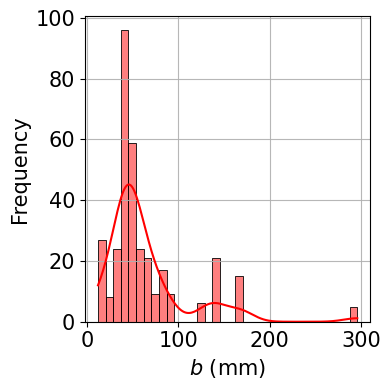

In [6]:
plt.figure(figsize=(4, 4))
sns.histplot(data=df, x='Espaçamento entre as barras (mm)', kde=True, color="red")
plt.xlabel('$b$ (mm)', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout() # Ajusta o layout para evitar que os rótulos fiquem cortados
plt.grid(True, linestyle='-', alpha=0.9)
plt.savefig('images/b_mm.png', dpi=300)
plt.show()
plt.close()

In [7]:
import pandas as pd

file_path = "banco de dados daniel.xlsx"
sheet_name = "Modelos normativos e empíricos"
df = pd.read_excel(file_path, sheet_name=sheet_name)
df.drop(columns=["Autor"], inplace=True)
df.columns

Index(['wexp (mm)', 'fib Model Code 2010', 'fib Model Code 2020', 'Eurocode 2',
       'NBR 6118 - wk1 - fissuração estabilizada',
       'NBR 6118 - wk2 - fissuração não estabilizada', 'Clark (1956)',
       'Leonhardt (1977)', 'Desayi e Ganesan (1985)', 'Oh e Kang (1987)',
       'Caldas (1997)', 'Gergely e Lutz (1968)', ' b  variável e < 0,6',
       'equação (15) do artigo de Belarbi e Hsu (1994)',
       'Beta conforme Fields e Bischoff (2004)', 'slip de Yuan et al. (2025)',
       'slip de Biscaia e Soares (2020)'],
      dtype='object')

In [8]:
# coluna experimental
wexp_col = "wexp (mm)"

# percorre todas as colunas numéricas, exceto a experimental
for col in df.select_dtypes(include="number").columns:
    if col == wexp_col:
        continue
    df[f"{col} / wexp"] = df[col] / df[wexp_col]

df.head()

,wexp (mm),fib Model Code 2010,fib Model Code 2020,Eurocode 2,NBR 6118 - wk1 - fissuração estabilizada,NBR 6118 - wk2 - fissuração não estabilizada,Clark (1956),Leonhardt (1977),Desayi e Ganesan (1985),Oh e Kang (1987),Caldas (1997),Gergely e Lutz (1968),"b variável e < 0,6",equação (15) do artigo de Belarbi e Hsu (1994),Beta conforme Fields e Bischoff (2004),slip de Yuan et al. (2025),slip de Biscaia e Soares (2020),fib Model Code 2010 / wexp,fib Model Code 2020 / wexp,Eurocode 2 / wexp,NBR 6118 - wk1 - fissuração estabilizada / wexp,NBR 6118 - wk2 - fissuração não estabilizada / wexp,Clark (1956) / wexp,Leonhardt (1977) / wexp,Desayi e Ganesan (1985) / wexp,Oh e Kang (1987) / wexp,Caldas (1997) / wexp,Gergely e Lutz (1968) / wexp,"b variável e < 0,6 / wexp",equação (15) do artigo de Belarbi e Hsu (1994) / wexp,Beta conforme Fields e Bischoff (2004) / wexp,slip de Yuan et al. (2025) / wexp,slip de Biscaia e Soares (2020) / wexp
0,0.16,0.125734,0.086159,0.125292,0.262468,0.157380,0.181006,0.296374,0.312684,0.185969,0.129998,0.241528,0.102130,0.149956,0.116566,0.109686,0.082007,0.785838,0.538496,0.783073,1.640424,0.983623,1.131289,1.852338,1.954276,1.162307,0.812485,1.509550,0.638311,0.937226,0.728538,0.685535,0.512541
1,0.23,0.176982,0.147127,0.176359,0.344489,0.271111,0.244363,0.447049,0.410398,0.256204,0.174746,0.317005,0.190783,0.204348,0.197288,0.193326,0.156266,0.769488,0.639681,0.766780,1.497778,1.178744,1.062446,1.943692,1.784339,1.113929,0.759763,1.378284,0.829489,0.888470,0.857774,0.840549,0.679418
2,0.24,0.184078,0.155568,0.183430,0.355846,0.289281,0.253135,0.467000,0.423928,0.265928,0.180941,0.327456,0.203058,0.212052,0.208041,0.205301,0.167096,0.766992,0.648201,0.764293,1.482691,1.205338,1.054729,1.945832,1.766365,1.108035,0.753923,1.364401,0.846073,0.883550,0.866837,0.855420,0.696232
3,0.27,0.218769,0.196838,0.217999,0.411368,0.386596,0.296022,0.562498,0.490072,0.313472,0.211232,0.378549,0.263069,0.250139,0.259368,0.265222,0.221958,0.810256,0.729030,0.807405,1.523584,1.431836,1.096379,2.083324,1.815083,1.161007,0.782342,1.402032,0.974328,0.926442,0.960621,0.982303,0.822067
4,0.35,0.286574,0.277502,0.285566,0.519888,0.617471,0.379848,0.742678,0.619355,0.406398,0.270437,0.478411,0.380363,0.311870,0.354810,0.388948,0.338382,0.818784,0.792864,0.815903,1.485395,1.764202,1.085279,2.121938,1.769586,1.161136,0.772678,1.366889,1.086752,0.891058,1.013742,1.111280,0.966805


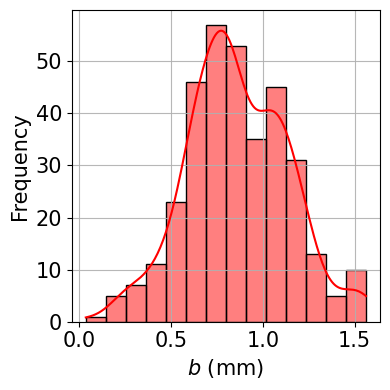

In [9]:
plt.figure(figsize=(4, 4))
sns.histplot(data=df, x='fib Model Code 2010 / wexp', kde=True, color="red")
plt.xlabel('$b$ (mm)', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout() # Ajusta o layout para evitar que os rótulos fiquem cortados
plt.grid(True, linestyle='-', alpha=0.9)
plt.savefig('images/b_mm.png', dpi=300)
plt.show()
plt.close()

In [10]:
# estatísticas básicas
df.drop(columns=['wexp (mm)', 'fib Model Code 2010', 'fib Model Code 2020', 'Eurocode 2',
       'NBR 6118 - wk1 - fissuração estabilizada',
       'NBR 6118 - wk2 - fissuração não estabilizada', 'Clark (1956)',
       'Leonhardt (1977)', 'Desayi e Ganesan (1985)', 'Oh e Kang (1987)',
       'Caldas (1997)', 'Gergely e Lutz (1968)', ' b  variável e < 0,6',
       'equação (15) do artigo de Belarbi e Hsu (1994)',
       'Beta conforme Fields e Bischoff (2004)', 'slip de Yuan et al. (2025)',
       'slip de Biscaia e Soares (2020)'], inplace=True)
desc = df.describe().T

# skewness e kurtosis
desc["skewness"] = df.skew()
desc["kurtosis"] = df.kurtosis()
desc_rounded = desc.round(2)
desc_rounded.drop(columns=["count"], inplace=True)
desc_rounded

,mean,std,min,25%,50%,75%,max,skewness,kurtosis
fib Model Code 2010 / wexp,0.86,0.28,0.04,0.67,0.83,1.06,1.56,0.09,0.06
fib Model Code 2020 / wexp,0.85,0.25,0.19,0.67,0.85,1.00,1.57,0.30,0.11
Eurocode 2 / wexp,0.91,0.31,0.24,0.72,0.87,1.08,2.02,0.82,1.27
NBR 6118 - wk1 - fissuração estabilizada / wexp,1.11,0.34,0.24,0.88,1.15,1.36,2.01,-0.13,-0.42
NBR 6118 - wk2 - fissuração não estabilizada / wexp,1.25,0.62,0.20,0.84,1.13,1.60,4.54,1.48,4.16
Clark (1956) / wexp,0.94,0.44,0.16,0.60,0.84,1.17,2.19,0.88,0.28
Leonhardt (1977) / wexp,1.36,0.43,0.17,1.08,1.37,1.61,2.41,-0.17,-0.10
Desayi e Ganesan (1985) / wexp,1.16,0.45,0.40,0.79,1.13,1.48,2.36,0.40,-0.68
Oh e Kang (1987) / wexp,0.88,0.30,0.25,0.65,0.88,1.11,1.55,-0.11,-0.74
Caldas (1997) / wexp,0.81,0.22,0.32,0.68,0.79,0.92,1.68,0.73,1.50


In [11]:
print(desc_rounded.reset_index().to_latex(
    index=False,
    escape=True, 
    caption="Descriptive statistics of the ratio $w_{num}/w_{exp}$.", 
    label="tab:descriptive_stats_wn_div_wexp",
    float_format="%.2f"
))

\begin{table}
\caption{Descriptive statistics of the ratio $w_{num}/w_{exp}$.}
\label{tab:descriptive_stats_wn_div_wexp}
\begin{tabular}{lrrrrrrrrr}
\toprule
index & mean & std & min & 25\% & 50\% & 75\% & max & skewness & kurtosis \\
\midrule
fib Model Code 2010 / wexp & 0.86 & 0.28 & 0.04 & 0.67 & 0.83 & 1.06 & 1.56 & 0.09 & 0.06 \\
fib Model Code 2020 / wexp & 0.85 & 0.25 & 0.19 & 0.67 & 0.85 & 1.00 & 1.57 & 0.30 & 0.11 \\
Eurocode 2 / wexp & 0.91 & 0.31 & 0.24 & 0.72 & 0.87 & 1.08 & 2.02 & 0.82 & 1.27 \\
NBR 6118 - wk1 - fissuração estabilizada / wexp & 1.11 & 0.34 & 0.24 & 0.88 & 1.15 & 1.36 & 2.01 & -0.13 & -0.42 \\
NBR 6118 - wk2 - fissuração não estabilizada / wexp & 1.25 & 0.62 & 0.20 & 0.84 & 1.13 & 1.60 & 4.54 & 1.48 & 4.16 \\
Clark (1956) / wexp & 0.94 & 0.44 & 0.16 & 0.60 & 0.84 & 1.17 & 2.19 & 0.88 & 0.28 \\
Leonhardt (1977) / wexp & 1.36 & 0.43 & 0.17 & 1.08 & 1.37 & 1.61 & 2.41 & -0.17 & -0.10 \\
Desayi e Ganesan (1985) / wexp & 1.16 & 0.45 & 0.40 & 0.79 & 1.13 & 1.48 &